🔍 Lade Stundenwerte für Juli 2016...
✅ Daten erfolgreich geladen! Generiere Chart...


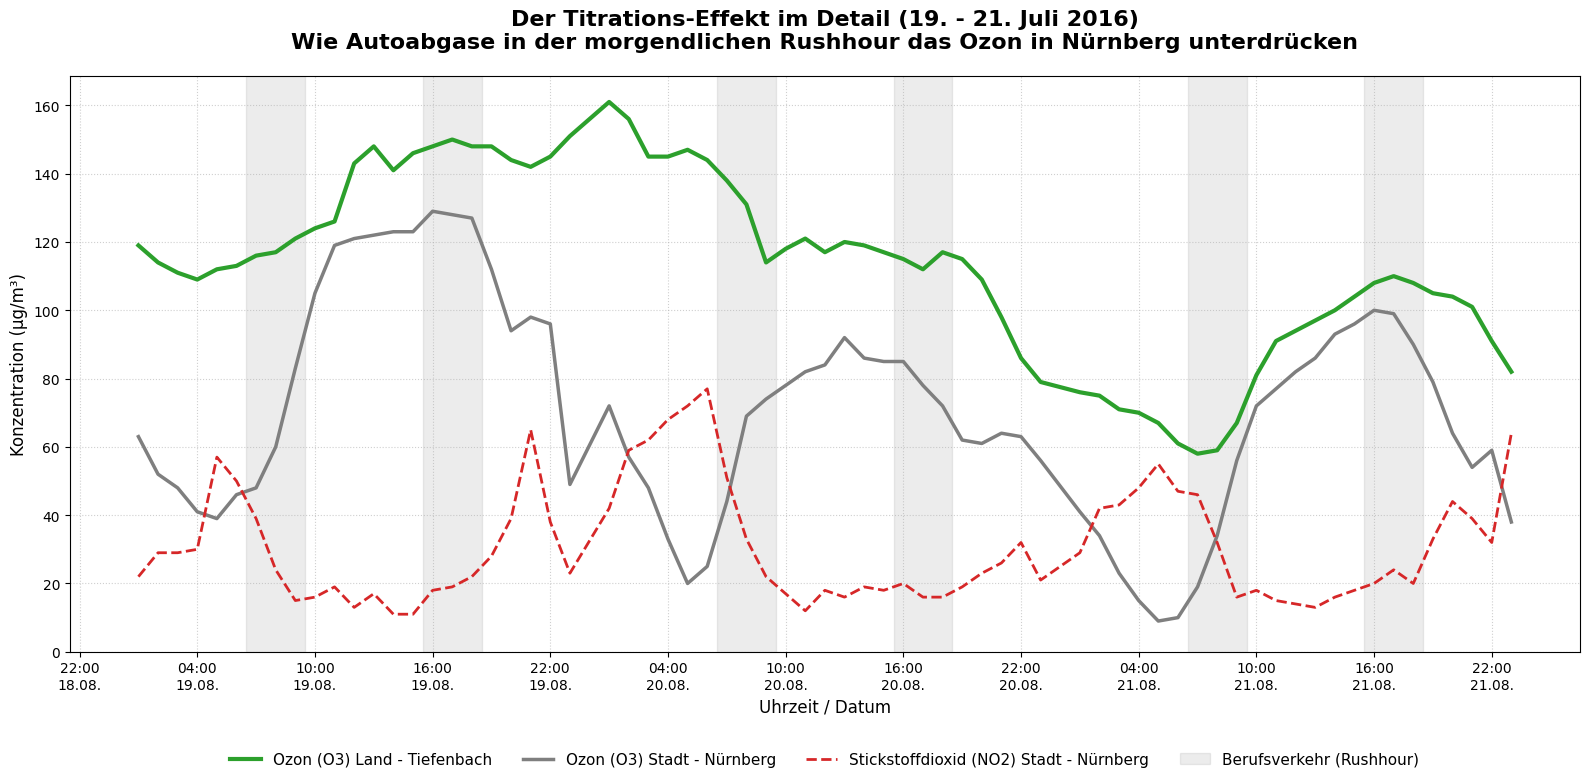

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

print("🔍 Lade Stundenwerte für Juli 2016...")

# ==========================================
# 1. Zeitfenster definieren (Heiße Tage 2018)
# ==========================================
start_date = '2018-08-19'
end_date = '2018-08-21'

# ==========================================
# 2. Nürnberg (Stadt) - Stundenwerte laden
# ==========================================
df_stadt = pd.read_csv('data/Schadstoff_Wetter.csv')
df_stadt['timestamp'] = pd.to_datetime(df_stadt['datum']) + pd.to_timedelta(df_stadt['stunde'] - 1, unit='h')

mask_stadt = (df_stadt['timestamp'] >= start_date) & (df_stadt['timestamp'] <= end_date + ' 23:59:59')
df_stadt_hourly = df_stadt.loc[mask_stadt, ['timestamp', 'o3', 'no2']].copy()
df_stadt_hourly.rename(columns={'o3': 'o3_stadt', 'no2': 'no2_stadt'}, inplace=True)

# ==========================================
# 3. Tiefenbach (Land) - aus vorbereiteter Parquet
# ==========================================
df_land = pd.read_parquet('data/o3_tiefenbach_2018.parquet')

mask_land = (df_land['timestamp'] >= start_date) & (df_land['timestamp'] <= end_date + ' 23:59:59')
df_land_hourly = df_land.loc[mask_land].copy()

# ==========================================
# 4. SICHERHEITS-CHECK & Plotting
# ==========================================
if df_land_hourly.empty:
    print("❌ FEHLER: Keine Land-Daten gefunden. Bitte prüfe den Dateinamen 'data/o3_tiefenbach_2018.parquet'")
elif df_stadt_hourly.empty:
    print("❌ FEHLER: Keine Stadt-Daten für diesen Zeitraum in Nürnberg gefunden.")
else:
    print("✅ Daten erfolgreich geladen! Generiere Chart...")
    
    df_merged = pd.merge(df_stadt_hourly, df_land_hourly, on='timestamp', how='inner')
    df_merged.set_index('timestamp', inplace=True)
    df_merged.sort_index(inplace=True)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(16, 8))

    ax.plot(df_merged.index, df_merged['o3_land'], label='Ozon (O3) Land - Tiefenbach', color='#2ca02c', linewidth=3)
    ax.plot(df_merged.index, df_merged['o3_stadt'], label='Ozon (O3) Stadt - Nürnberg', color='#7f7f7f', linewidth=2.5)
    ax.plot(df_merged.index, df_merged['no2_stadt'], label='Stickstoffdioxid (NO2) Stadt - Nürnberg', color='#d62728', linestyle='--', linewidth=2)

    # Berufsverkehr-Zonen einzeichnen
    days = df_merged.index.normalize().unique()
    for day in days:
        rush_morgen_start = day + pd.Timedelta(hours=6, minutes=30)
        rush_morgen_end = day + pd.Timedelta(hours=9, minutes=30)
        ax.axvspan(rush_morgen_start, rush_morgen_end, color='gray', alpha=0.15)
        
        rush_abend_start = day + pd.Timedelta(hours=15, minutes=30)
        rush_abend_end = day + pd.Timedelta(hours=18, minutes=30)
        ax.axvspan(rush_abend_start, rush_abend_end, color='gray', alpha=0.15)

    # Achsen & Layout
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%d.%m.'))
    ax.set_xlabel('Uhrzeit / Datum', fontsize=12)
    ax.set_ylabel('Konzentration (µg/m³)', fontsize=12)
    ax.set_ylim(bottom=0)

    # Legende
    rushhour_patch = mpatches.Patch(color='gray', alpha=0.15, label='Berufsverkehr (Rushhour)')
    handles, labels = ax.get_legend_handles_labels()
    handles.append(rushhour_patch)
    labels.append('Berufsverkehr (Rushhour)')
    
    plt.title('Der Titrations-Effekt im Detail (19. - 21. August 2018)\nWie Autoabgase in der morgendlichen Rushhour das Ozon in Nürnberg unterdrücken', fontsize=16, fontweight='bold', pad=20)
    ax.legend(handles=handles, labels=labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=11)
    
    ax.grid(True, linestyle=':', alpha=0.6)
    fig.tight_layout()
    plt.show()

🔥 Starte die Hitzewellen-Analyse für August 2018...
📥 Lese Datei: data\O3_2018.xlsx
   ✔️ Passende Stundenwerte für Tiefenbach erfolgreich extrahiert.
✅ Daten erfolgreich zusammengeführt! Generiere Chart...


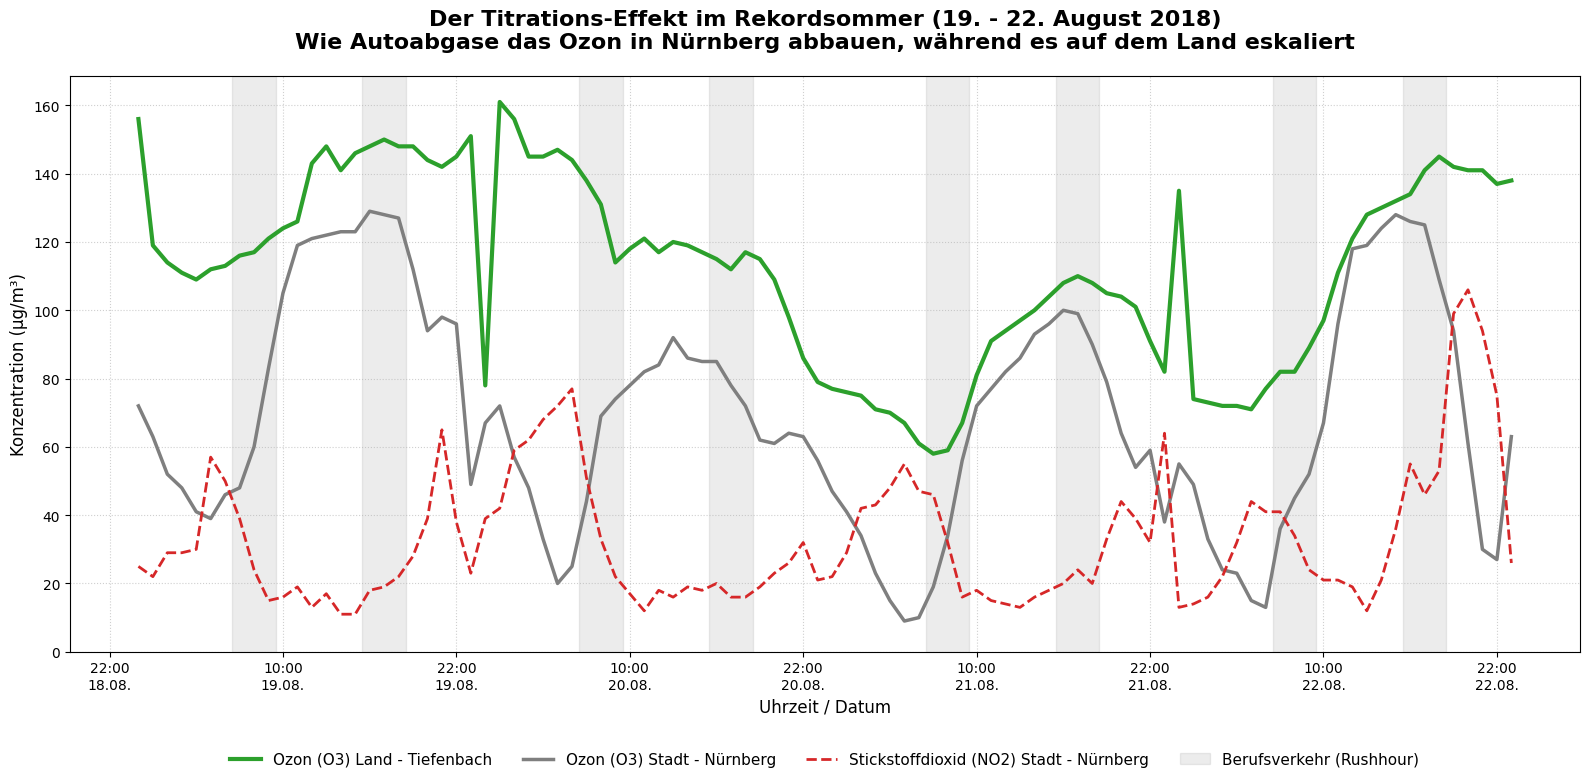

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import glob
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

print("🔥 Starte die Hitzewellen-Analyse für August 2018...")

# ==========================================
# 1. Zeitfenster definieren (Hitzewelle 2018)
# ==========================================
start_date = '2018-08-19'
end_date = '2018-08-22'

# ==========================================
# 2. Nürnberg (Stadt) - Stundenwerte
# ==========================================
df_stadt = pd.read_csv('data/Schadstoff_Wetter.csv')
df_stadt['timestamp'] = pd.to_datetime(df_stadt['datum']) + pd.to_timedelta(df_stadt['stunde'] - 1, unit='h')

mask_stadt = (df_stadt['timestamp'] >= start_date) & (df_stadt['timestamp'] <= end_date + ' 23:59:59')
df_stadt_hourly = df_stadt.loc[mask_stadt, ['timestamp', 'o3', 'no2']].copy()
df_stadt_hourly.rename(columns={'o3': 'o3_stadt', 'no2': 'no2_stadt'}, inplace=True)

# ==========================================
# 3. Tiefenbach (Land) - Der unverwundbare Parser
# ==========================================
excel_files = glob.glob("data/*2018*.xlsx")
ziel_station = "Tiefenbach"
df_land_hourly = pd.DataFrame()

if not excel_files:
    print("❌ FEHLER: Keine Datei mit '2018' und '.xlsx' im Namen gefunden!")
else:
    file = excel_files[0] 
    print(f"📥 Lese Datei: {file}")
    
    try:
        df_head = pd.read_excel(file, nrows=15, header=None)
        target_row = -1
        
        for r in range(len(df_head)):
            for c in range(len(df_head.columns)):
                if ziel_station.lower() in str(df_head.iloc[r, c]).lower():
                    target_row = r
                    break
            if target_row != -1: break
                
        if target_row != -1:
            df = pd.read_excel(file, header=target_row)
            time_col = df.columns[0]
            station_col = [col for col in df.columns if ziel_station.lower() in str(col).lower()][0]
            
            df_clean = df[[time_col, station_col]].copy()
            df_clean.columns = ['timestamp', 'o3_land']
            
            # --- DER FIX: Robuste Datumskonvertierung ---
            # 1. Alles zu String machen
            time_str = df_clean['timestamp'].astype(str)
            # 2. LfU "24:00" Besonderheit zu "00:00" patchen
            time_str = time_str.str.replace('24:00', '00:00')
            # 3. Pandas zwingen, den Tag zuerst zu lesen (Europäisches Format!)
            df_clean['timestamp'] = pd.to_datetime(time_str, dayfirst=True, errors='coerce')
            
            df_clean = df_clean.dropna(subset=['timestamp'])
            df_clean['o3_land'] = pd.to_numeric(df_clean['o3_land'], errors='coerce')
            
            # Filtern auf unsere Hitzewellen-Tage
            mask_land = (df_clean['timestamp'] >= start_date) & (df_clean['timestamp'] <= end_date + ' 23:59:59')
            df_land_hourly = df_clean.loc[mask_land].copy()
            print("   ✔️ Passende Stundenwerte für Tiefenbach erfolgreich extrahiert.")
        else:
            print(f"   ⚠️ Station '{ziel_station}' in der Datei nicht gefunden.")
    except Exception as e:
         print(f"   ❌ Fehler beim Verarbeiten von {file}: {e}")

# ==========================================
# 4. SICHERHEITS-CHECK & Plotting
# ==========================================
if df_land_hourly.empty:
    print("❌ FEHLER: Keine Land-Daten extrahiert.")
elif df_stadt_hourly.empty:
    print("❌ FEHLER: Keine Stadt-Daten für diesen Zeitraum in Nürnberg gefunden.")
else:
    print("✅ Daten erfolgreich zusammengeführt! Generiere Chart...")
    
    df_merged = pd.merge(df_stadt_hourly, df_land_hourly, on='timestamp', how='inner')
    df_merged.set_index('timestamp', inplace=True)
    df_merged.sort_index(inplace=True)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(16, 8))

    ax.plot(df_merged.index, df_merged['o3_land'], label='Ozon (O3) Land - Tiefenbach', color='#2ca02c', linewidth=3)
    ax.plot(df_merged.index, df_merged['o3_stadt'], label='Ozon (O3) Stadt - Nürnberg', color='#7f7f7f', linewidth=2.5)
    ax.plot(df_merged.index, df_merged['no2_stadt'], label='Stickstoffdioxid (NO2) Stadt - Nürnberg', color='#d62728', linestyle='--', linewidth=2)

    # Berufsverkehr-Zonen einzeichnen (Rushhour)
    days = df_merged.index.normalize().unique()
    for day in days:
        rush_morgen_start = day + pd.Timedelta(hours=6, minutes=30)
        rush_morgen_end = day + pd.Timedelta(hours=9, minutes=30)
        ax.axvspan(rush_morgen_start, rush_morgen_end, color='gray', alpha=0.15)
        
        rush_abend_start = day + pd.Timedelta(hours=15, minutes=30)
        rush_abend_end = day + pd.Timedelta(hours=18, minutes=30)
        ax.axvspan(rush_abend_start, rush_abend_end, color='gray', alpha=0.15)

    # Achsen & Layout
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=12)) 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%d.%m.'))
    
    ax.set_xlabel('Uhrzeit / Datum', fontsize=12)
    ax.set_ylabel('Konzentration (µg/m³)', fontsize=12)
    ax.set_ylim(bottom=0)

    rushhour_patch = mpatches.Patch(color='gray', alpha=0.15, label='Berufsverkehr (Rushhour)')
    handles, labels = ax.get_legend_handles_labels()
    handles.append(rushhour_patch)
    labels.append('Berufsverkehr (Rushhour)')
    
    plt.title('Der Titrations-Effekt im Rekordsommer (19. - 22. August 2018)\nWie Autoabgase das Ozon in Nürnberg abbauen, während es auf dem Land den natürlichen Sonnenrythmus widerspiegelt', fontsize=16, fontweight='bold', pad=20)
    ax.legend(handles=handles, labels=labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=11)
    
    ax.grid(True, linestyle=':', alpha=0.6)
    fig.tight_layout()
    plt.show()